# KWS 实验分析

依赖三张 CSV(由 `scripts/update_registry.py` 产出):

| 文件 | 含义 |
|---|---|
| `registry.csv` | 宽表 · 实验元数据 + 每 testset/backend 一组指标列 |
| `per_command.csv` | 长表 · 每行 = (exp, testset, backend, keyword) |
| `per_perf.csv` | 长表 · 每行 = (exp, scene, mode, ...) 性能 |

所有图表基于 **per_command 长表**,自动适配任何稀疏程度。
如果你的数据里没有 `keyword='all'` 的合计行,会自动按 TP/FP/FN 加总。

In [1]:
%matplotlib inline
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# 中文字体(有就用,没有就让它自己 fallback,不报错就行)
for fn in ['Noto Sans CJK SC', 'Noto Sans CJK JP', 'WenQuanYi Micro Hei',
           'PingFang SC', 'SimHei', 'Microsoft YaHei', 'Arial Unicode MS']:
    try:
        mpl.font_manager.findfont(fn, fallback_to_default=False)
        mpl.rcParams['font.sans-serif'] = [fn] + list(mpl.rcParams.get('font.sans-serif', []))
        mpl.rcParams['axes.unicode_minus'] = False
        break
    except Exception:
        pass

ROOT = Path('.').resolve()
if ROOT.name == 'scripts':
    ROOT = ROOT.parent

reg  = pd.read_csv(ROOT / 'registry.csv')    if (ROOT / 'registry.csv').exists()    else pd.DataFrame()
pc   = pd.read_csv(ROOT / 'per_command.csv') if (ROOT / 'per_command.csv').exists() else pd.DataFrame()
perf = pd.read_csv(ROOT / 'per_perf.csv')    if (ROOT / 'per_perf.csv').exists()    else pd.DataFrame()

# 拆 backend = base + tag(如 onnx-t0.20 -> base=onnx, tag=0.20)
def split_backend(b):
    if not isinstance(b, str): return ('', '')
    parts = b.split('-', 1)
    if len(parts) == 1: return (parts[0], '')
    base, tail = parts
    m = re.match(r'^t(.+)$', tail)
    return (base, m.group(1)) if m else (base, tail)

if len(pc):
    pc[['backend_base', 'tag']] = pc['backend'].apply(lambda b: pd.Series(split_backend(b)))

# 关键辅助:把 per_command 聚合成"每 (exp,testset,backend) 一行"的合计表
def aggregate_all(pc: pd.DataFrame) -> pd.DataFrame:
    if pc.empty:
        return pd.DataFrame()
    has_all = pc['keyword'].str.lower().eq('all').any() if 'keyword' in pc.columns else False
    if has_all:
        return pc[pc['keyword'].str.lower() == 'all'].copy()
    # 否则按 TP/FP/FN 聚合所有 keyword
    g = (pc.groupby(['exp_id', 'testset', 'backend', 'backend_base', 'tag'], dropna=False)
            .agg(TP=('TP', 'sum'), FP=('FP', 'sum'),
                 FN=('FN', 'sum'), TN=('TN', 'sum'),
                 fa_per_hour=('fa_per_hour', 'mean'),
                 n_keywords=('keyword', 'nunique'))
            .reset_index())
    g['recall']    = g['TP'] / (g['TP'] + g['FN']).replace(0, np.nan)
    g['precision'] = g['TP'] / (g['TP'] + g['FP']).replace(0, np.nan)
    g['f1']        = 2 * g['precision'] * g['recall'] / (g['precision'] + g['recall'])
    g['fpr']       = g['FP'] / (g['FP'] + g['TN']).replace(0, np.nan)
    g['keyword']   = '(aggregated)'
    return g

pc_all = aggregate_all(pc)

print(f'registry    : {len(reg):3d} 行')
print(f'per_command : {len(pc):3d} 行  '
      f'({pc["testset"].nunique() if len(pc) else 0} 个 testset · '
      f'{pc["exp_id"].nunique() if len(pc) else 0} 个实验 · '
      f'{pc["keyword"].nunique() if len(pc) else 0} 个 keyword)')
print(f'pc_all      : {len(pc_all):3d} 行 (每个 (exp,testset,backend) 一条合计)')
print(f'per_perf    : {len(perf):3d} 行')
pc_all.head()

registry    :   3 行
per_command :  12 行  (4 个 testset · 3 个实验 · 1 个 keyword)
pc_all      :  12 行 (每个 (exp,testset,backend) 一条合计)
per_perf    :   0 行


,exp_id,testset,backend,backend_base,tag,TP,FP,FN,TN,fa_per_hour,n_keywords,recall,precision,f1,fpr,keyword
0,exp001,elevenlabs,onnx,onnx,,429,0,66,0,NaN,1,0.866667,1.0000,0.928571,NaN,(aggregated)
1,exp001,test_wav,onnx,onnx,,1,0,1,0,NaN,1,0.500000,1.0000,0.666667,NaN,(aggregated)
2,exp002,real_person_test,onnx-t0.20,onnx,0.20,43,37,636,50,NaN,1,0.063328,0.5375,0.113307,0.425287,(aggregated)
3,exp002,real_person_test,onnx-t0.25,onnx,0.25,43,37,636,50,NaN,1,0.063328,0.5375,0.113307,0.425287,(aggregated)
4,exp002,real_person_test,onnx-t0.30,onnx,0.30,43,37,636,50,NaN,1,0.063328,0.5375,0.113307,0.425287,(aggregated)


## 1. 覆盖矩阵:谁在什么 testset 上测过?

格子里是该 (exp, testset) 下所有出现过的 backend。空白 = 没测。

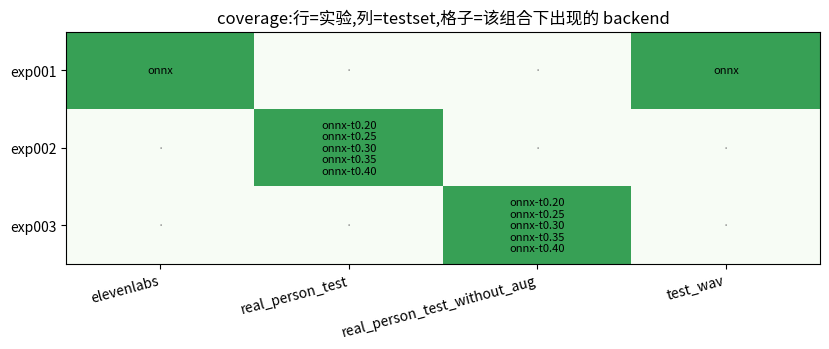

In [2]:
def coverage_matrix(pc):
    if pc.empty:
        print('per_command 为空'); return
    grid = (pc.groupby(['exp_id', 'testset'])['backend']
              .apply(lambda s: '\n'.join(sorted(set(s))))
              .unstack(fill_value=''))
    fig, ax = plt.subplots(figsize=(max(8, 1.6 * len(grid.columns) + 2),
                                    max(2, 0.7 * len(grid) + 1.5)))
    mask = (grid != '').astype(int).values
    ax.imshow(mask, aspect='auto', cmap='Greens', vmin=0, vmax=1.5)
    ax.set_xticks(range(len(grid.columns)))
    ax.set_xticklabels(grid.columns, rotation=15, ha='right')
    ax.set_yticks(range(len(grid.index)))
    ax.set_yticklabels(grid.index)
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            v = grid.values[i, j]
            ax.text(j, i, v if v else '·', ha='center', va='center',
                    fontsize=8, color='black' if v else 'gray')
    ax.set_title('coverage:行=实验,列=testset,格子=该组合下出现的 backend')
    plt.tight_layout(); plt.show()

coverage_matrix(pc)

## 2. 总览长表(高亮每个 testset 的最佳 Recall)

In [3]:
def overview_long(pc_all):
    if pc_all.empty:
        print('没有数据'); return
    cols = ['exp_id', 'testset', 'backend_base', 'tag',
            'recall', 'precision', 'f1', 'TP', 'FP', 'FN']
    cols = [c for c in cols if c in pc_all.columns]
    out = (pc_all[cols].copy()
                       .sort_values(['testset', 'recall'], ascending=[True, False])
                       .reset_index(drop=True))
    def hl_per_testset(s):
        # 在同 testset 内高亮 recall 最大行
        styles = ['' ] * len(s)
        for ts, g in out.groupby('testset'):
            if g['recall'].notna().any():
                idx_max = g['recall'].idxmax()
                styles[idx_max] = 'background-color: #d9f7be; font-weight: bold'
        return styles
    sty = (out.style.format({'recall': '{:.3f}', 'precision': '{:.3f}', 'f1': '{:.3f}'},
                            na_rep='—')
                   .apply(hl_per_testset, subset=['recall']))
    return sty

overview_long(pc_all)

,exp_id,testset,backend_base,tag,recall,precision,f1,TP,FP,FN
0,exp001,elevenlabs,onnx,,0.867,1.000,0.929,429,0,66
1,exp002,real_person_test,onnx,0.20,0.063,0.537,0.113,43,37,636
2,exp002,real_person_test,onnx,0.25,0.063,0.537,0.113,43,37,636
3,exp002,real_person_test,onnx,0.30,0.063,0.537,0.113,43,37,636
4,exp002,real_person_test,onnx,0.35,0.063,0.537,0.113,43,37,636
5,exp002,real_person_test,onnx,0.40,0.063,0.537,0.113,43,37,636
6,exp003,real_person_test_without_aug,onnx,0.20,0.579,0.550,0.564,11,9,8
7,exp003,real_person_test_without_aug,onnx,0.25,0.579,0.550,0.564,11,9,8
8,exp003,real_person_test_without_aug,onnx,0.30,0.579,0.550,0.564,11,9,8
9,exp003,real_person_test_without_aug,onnx,0.35,0.579,0.550,0.564,11,9,8


## 3. 每 testset 的对比柱状图

每个 testset 一张图,横轴 = exp_id+backend,Y = Recall / Precision / F1。
比长表更直观,坏的会一眼看到。

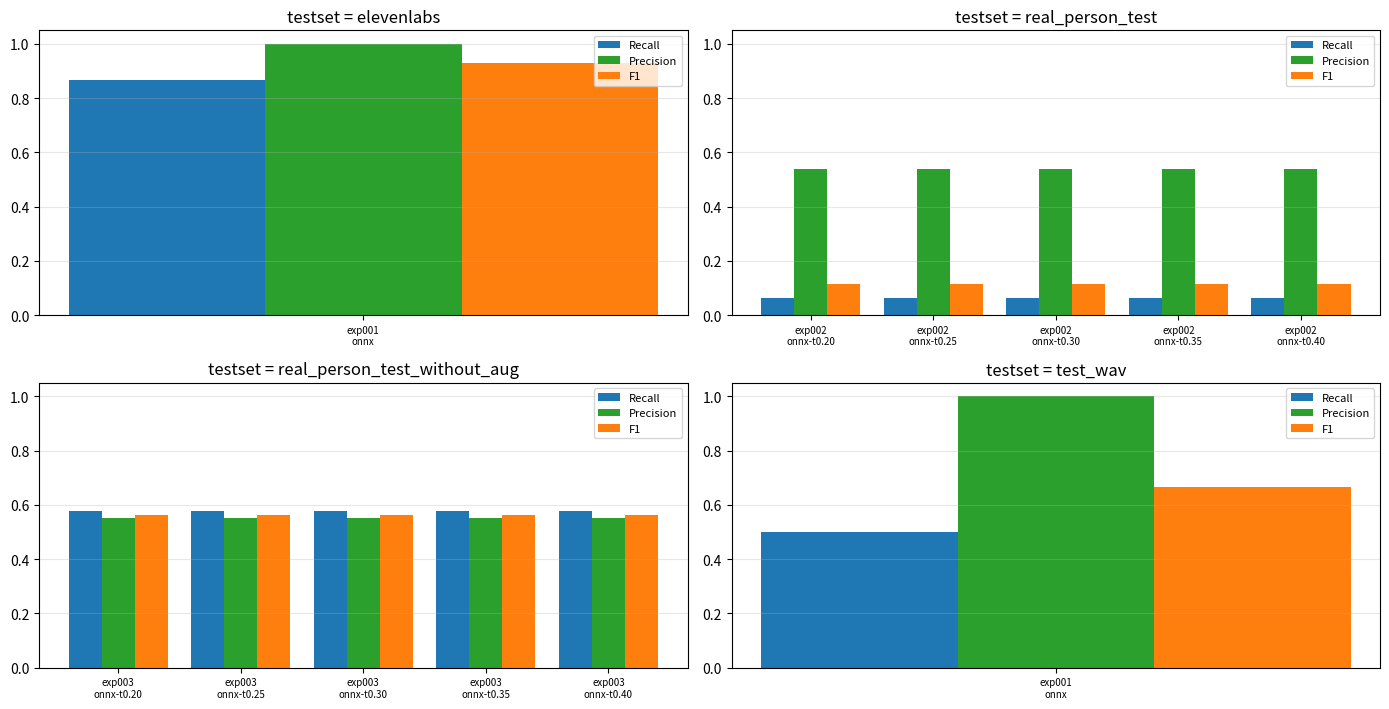

In [4]:
def per_testset_bars(pc_all):
    if pc_all.empty: return
    testsets = sorted(pc_all['testset'].unique())
    n = len(testsets)
    if n == 0: return
    cols = min(2, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 3.6 * rows), squeeze=False)
    for ax, ts in zip(axes.flat, testsets):
        sub = pc_all[pc_all['testset'] == ts].copy()
        if sub.empty: continue
        sub['label'] = sub['exp_id'].astype(str) + '\n' + sub['backend'].astype(str)
        sub = sub.sort_values('label')
        x = np.arange(len(sub)); w = 0.27
        ax.bar(x - w, sub['recall'].fillna(0),    w, label='Recall',    color='#1f77b4')
        ax.bar(x,     sub['precision'].fillna(0), w, label='Precision', color='#2ca02c')
        ax.bar(x + w, sub['f1'].fillna(0),        w, label='F1',        color='#ff7f0e')
        ax.set_xticks(x)
        ax.set_xticklabels(sub['label'], rotation=0, fontsize=7)
        ax.set_ylim(0, 1.05); ax.set_title(f'testset = {ts}')
        ax.grid(axis='y', alpha=0.3); ax.legend(fontsize=8, loc='upper right')
    for ax in axes.flat[n:]:
        ax.axis('off')
    plt.tight_layout(); plt.show()

per_testset_bars(pc_all)

## 4. 阈值扫描:R/P/F1 随 threshold 变化

同一个 `(exp_id, testset, backend_base)` 下若有 >=2 个 tag(threshold),自动画曲线。
**若曲线水平,说明 threshold 没真正生效,会标红色警告。**

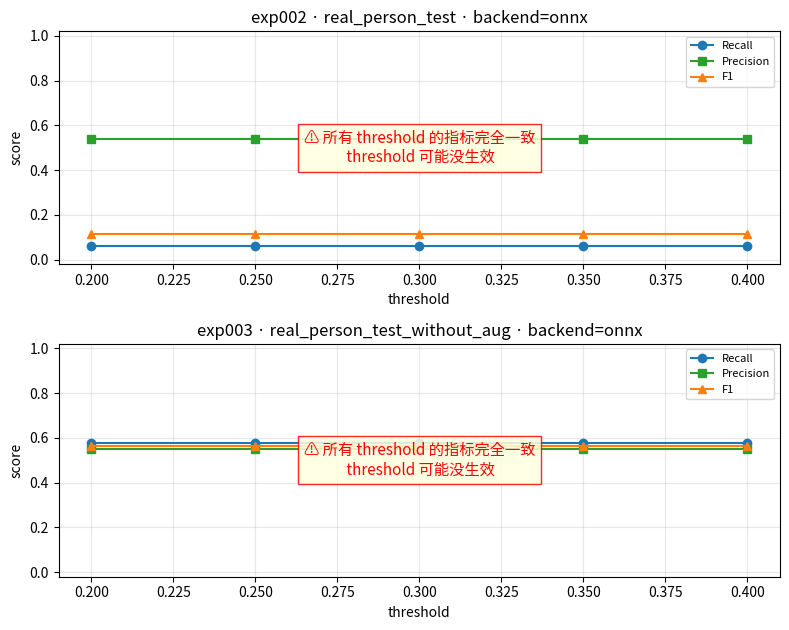

In [5]:
def threshold_sweep(pc_all):
    if pc_all.empty or 'tag' not in pc_all.columns:
        print('没有 tag 列'); return
    sub = pc_all[pc_all['tag'].astype(str).str.len() > 0].copy()
    if sub.empty:
        print('没有带 tag 的数据,跳过'); return
    sub['tag_num'] = pd.to_numeric(sub['tag'], errors='coerce')
    sub = sub.dropna(subset=['tag_num'])
    if sub.empty:
        print('tag 不是数值,跳过'); return
    groups = [(k, g) for k, g in sub.groupby(['exp_id', 'testset', 'backend_base'])
              if len(g) >= 2]
    if not groups:
        print('没有发现 >=2 个 tag 的同组数据'); return
    n = len(groups)
    fig, axes = plt.subplots(n, 1, figsize=(8, 3.2 * n), squeeze=False)
    for ax, (key, g) in zip(axes[:, 0], groups):
        g = g.sort_values('tag_num')
        ax.plot(g['tag_num'], g['recall'],    marker='o', label='Recall',    color='tab:blue')
        ax.plot(g['tag_num'], g['precision'], marker='s', label='Precision', color='tab:green')
        ax.plot(g['tag_num'], g['f1'],        marker='^', label='F1',        color='tab:orange')
        eid, ts, bk = key
        ax.set_title(f'{eid} · {ts} · backend={bk}')
        ax.set_xlabel('threshold'); ax.set_ylabel('score')
        ax.set_ylim(-0.02, 1.02); ax.grid(alpha=0.3); ax.legend(loc='best', fontsize=8)
        if g[['recall', 'precision', 'f1']].nunique().max() <= 1:
            ax.text(0.5, 0.5, '⚠ 所有 threshold 的指标完全一致\n threshold 可能没生效',
                    transform=ax.transAxes, ha='center', va='center',
                    fontsize=11, color='red',
                    bbox=dict(facecolor='lightyellow', edgecolor='red', alpha=0.85))
    plt.tight_layout(); plt.show()

threshold_sweep(pc_all)

## 5. Precision–Recall 散点(每 testset 一张)

X = Precision,Y = Recall。右上角越靠越好。每个点 = 一个 (exp, backend, tag) 组合。

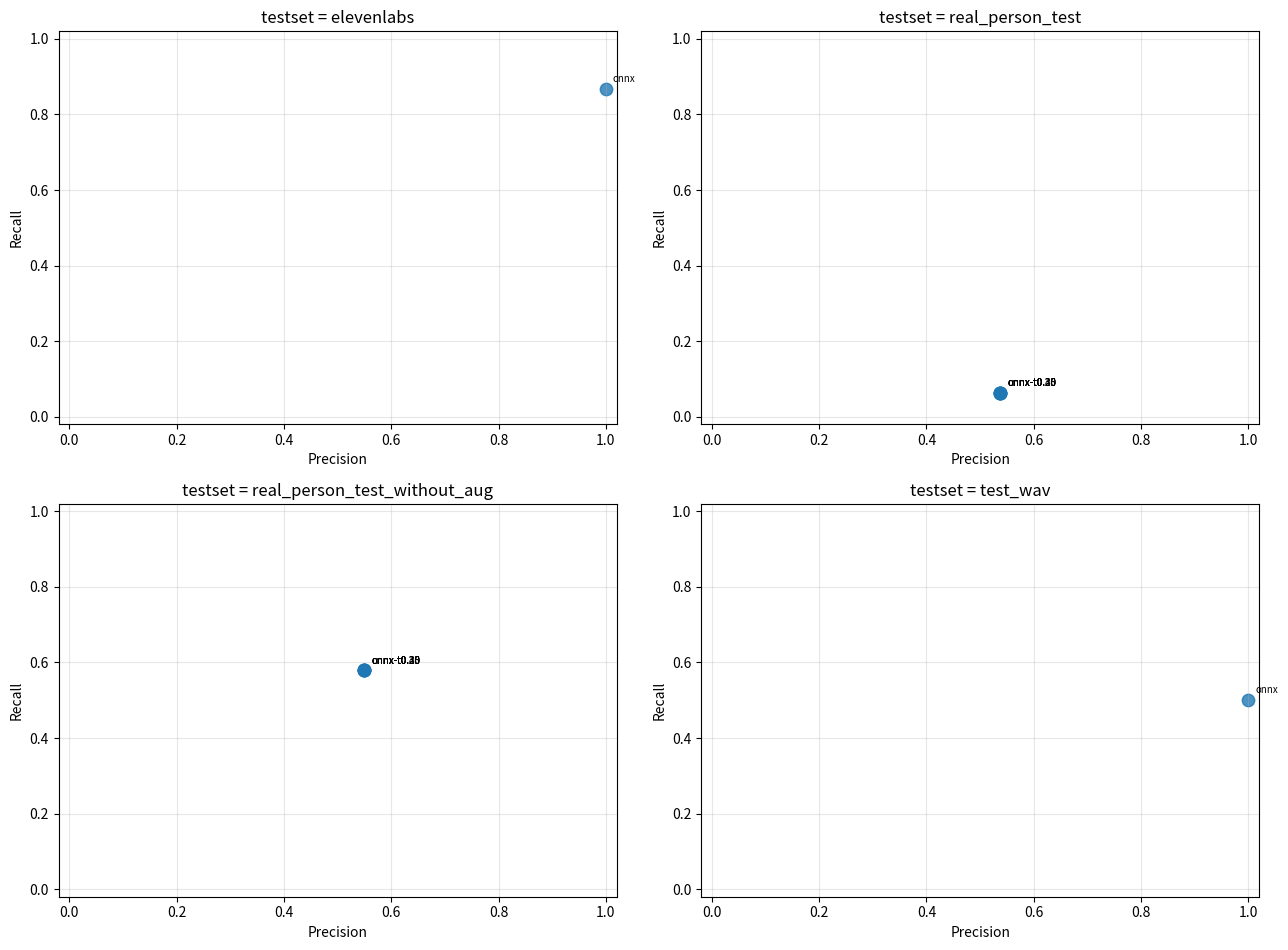

In [6]:
def pareto_per_testset(pc_all):
    if pc_all.empty: return
    testsets = sorted(pc_all['testset'].unique())
    n = len(testsets)
    if n == 0: return
    cols = min(2, n); rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6.5 * cols, 4.8 * rows), squeeze=False)
    for ax, ts in zip(axes.flat, testsets):
        sub = pc_all[pc_all['testset'] == ts]
        for eid, g in sub.groupby('exp_id'):
            ax.scatter(g['precision'], g['recall'], s=80, label=eid, alpha=0.8)
            for _, r in g.iterrows():
                lbl = r['backend']
                ax.annotate(lbl, (r['precision'], r['recall']),
                            xytext=(5, 5), textcoords='offset points', fontsize=7)
        ax.set_xlabel('Precision'); ax.set_ylabel('Recall')
        ax.set_title(f'testset = {ts}')
        ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
        ax.grid(alpha=0.3)
        if sub["exp_id"].nunique() > 1:
            ax.legend(fontsize=8, loc="lower right")
    for ax in axes.flat[n:]:
        ax.axis('off')
    plt.tight_layout(); plt.show()

pareto_per_testset(pc_all)

## 6. Per-keyword 热力图(多关键词实验才出)

对每个 (testset, backend),如果有 >=2 个非 'all' 关键词,出热力图。

In [7]:
def keyword_heatmap(pc, metric='recall'):
    if pc.empty: return
    sub = pc[pc['keyword'].str.lower() != 'all'].copy()
    if sub.empty:
        print('per_command 全是 all-keyword 行,无 per-keyword 数据'); return
    any_plot = False
    for (ts, bk), g in sub.groupby(['testset', 'backend']):
        if g['keyword'].nunique() < 2:
            continue
        any_plot = True
        tab = g.pivot_table(index='keyword', columns='exp_id',
                            values=metric, aggfunc='first')
        fig, ax = plt.subplots(figsize=(max(5, 0.7 * len(tab.columns) + 2),
                                        max(3, 0.35 * len(tab) + 1.5)))
        im = ax.imshow(tab.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
        ax.set_xticks(range(len(tab.columns)))
        ax.set_xticklabels(tab.columns, rotation=30, ha='right')
        ax.set_yticks(range(len(tab.index)))
        ax.set_yticklabels(tab.index)
        for i in range(tab.shape[0]):
            for j in range(tab.shape[1]):
                v = tab.values[i, j]
                if pd.notna(v):
                    ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                            fontsize=8, color='black')
        fig.colorbar(im, ax=ax, label=metric)
        ax.set_title(f'{metric} per keyword  —  {ts} / {bk}')
        plt.tight_layout(); plt.show()
    if not any_plot:
        print('每个 (testset, backend) 组合只有 1 个 keyword,跳过热力图')

keyword_heatmap(pc, 'recall')

每个 (testset, backend) 组合只有 1 个 keyword,跳过热力图


## 7. PT vs ONNX 部署差距(只比无 tag 的 baseline)

每个 testset 对比训练端(pt)和部署端(onnx)的 Recall 差距。

In [8]:
def pt_vs_onnx(pc_all):
    if pc_all.empty: return
    df = pc_all[pc_all['backend_base'].isin(['pt', 'onnx'])]
    df = df[df['tag'].astype(str) == '']
    if df.empty:
        print('没有 pt/onnx (无 tag) 的数据'); return
    pivot = df.pivot_table(index=['exp_id', 'testset'],
                           columns='backend_base', values='recall',
                           aggfunc='first').reset_index()
    if not {'pt', 'onnx'}.issubset(pivot.columns):
        print(f'缺 pt 或 onnx 列,有的是: {list(pivot.columns)}'); return
    pivot = pivot.dropna(subset=['pt', 'onnx'])
    if pivot.empty:
        print('没有 pt/onnx 同时存在的实验'); return
    pivot['delta_onnx_minus_pt'] = pivot['onnx'] - pivot['pt']
    return pivot.sort_values('delta_onnx_minus_pt').style.format(
        {'pt': '{:.3f}', 'onnx': '{:.3f}', 'delta_onnx_minus_pt': '{:+.3f}'}, na_rep='—')

pt_vs_onnx(pc_all)

缺 pt 或 onnx 列,有的是: ['exp_id', 'testset', 'onnx']


## 8. 性能 · 并发扫描

In [9]:
def perf_concurrency_curve(perf):
    if perf.empty:
        print('per_perf.csv 为空,跳过'); return
    df = perf[perf['mode'] == 'concurrent'].copy()
    if df.empty:
        print('没有 concurrent 模式记录'); return
    df['concurrency'] = pd.to_numeric(df['concurrency'], errors='coerce')
    df = df.dropna(subset=['concurrency']).sort_values('concurrency')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    for eid, sub in df.groupby('exp_id'):
        ax1.plot(sub['concurrency'], sub['throughput_cps'], marker='o', label=eid)
        ax2.plot(sub['concurrency'], sub['latency_p95'],    marker='o', label=eid)
    ax1.set_xlabel('concurrency'); ax1.set_ylabel('throughput (calls/sec)')
    ax1.set_title('Throughput vs concurrency'); ax1.grid(alpha=0.3); ax1.legend()
    ax2.set_xlabel('concurrency'); ax2.set_ylabel('latency P95 (s)')
    ax2.set_title('P95 latency vs concurrency'); ax2.grid(alpha=0.3); ax2.legend()
    plt.tight_layout(); plt.show()

perf_concurrency_curve(perf)

per_perf.csv 为空,跳过


## 9. 性能 · 延迟分布(各场景 P50/P95/P99)

In [10]:
def perf_latency_bars(perf):
    if perf.empty: return
    df = perf.copy().sort_values(['exp_id', 'scene'])
    x = np.arange(len(df)); w = 0.25
    fig, ax = plt.subplots(figsize=(max(7, len(df) * 0.7), 4))
    ax.bar(x - w, pd.to_numeric(df['latency_p50'], errors='coerce'), w, label='P50')
    ax.bar(x,     pd.to_numeric(df['latency_p95'], errors='coerce'), w, label='P95')
    ax.bar(x + w, pd.to_numeric(df['latency_p99'], errors='coerce'), w, label='P99')
    ax.set_xticks(x)
    ax.set_xticklabels([f"{r.exp_id}\n{r.scene}" for r in df.itertuples()],
                       rotation=0, fontsize=8)
    ax.set_ylabel('latency (s)')
    ax.set_title('Per-scene latency distribution')
    ax.grid(axis='y', alpha=0.3); ax.legend()
    plt.tight_layout(); plt.show()

perf_latency_bars(perf)

## 10. 性能 · CPU 预算扫描(cpu_sweep)

读取 `runs/*/metrics/perf-cpu_sweep_*.csv` + 配对 JSON,每份 sweep 一张子图:

- **左轴**:`cpu_p95` 实线 — 口径见 JSON `cpu_budget_mode`(`per_core`:每个核 100%;`total`:全机 100%)
- **右轴**:`lat_p95 × 1000` ms 虚线
- 横线 = JSON 里的 `target_cpu`
- 竖线 = `max_concurrency_under_budget`(满足 `cpu_p95 ≤ target_cpu` 的最大并发)

子图标题带 `inner_mode` / `affinity_cores` / `pacing`,便于对照部署形态。

In [ ]:
import json as _json

def _load_cpu_sweeps(root: Path):
    """扫描 runs/*/metrics/perf-cpu_sweep_*.csv,返回 [(meta_dict, points_df), ...]。"""
    out = []
    for csv_path in sorted(root.glob('runs/*/metrics/perf-cpu_sweep_*.csv')):
        json_path = csv_path.with_suffix('.json')
        if not json_path.exists():
            continue
        meta = _json.loads(json_path.read_text())
        r = meta.get('result', {})
        df = pd.read_csv(csv_path).sort_values('concurrency')
        out.append({
            'csv': csv_path,
            'exp_id': csv_path.parents[1].name,
            'scene': meta.get('scene', csv_path.stem),
            'inner_mode': r.get('inner_mode', '?'),
            'pacing': r.get('pacing', '?'),
            'target_cpu': float(r.get('target_cpu', 70.0)),
            'budget_mode': r.get('cpu_budget_mode', 'per_core'),
            'cpu_upper': float(r.get('cpu_upper_bound', 100.0)),
            'affinity_cores': r.get('affinity_cores'),
            'max_conc': r.get('max_concurrency_under_budget', 0),
            'df': df,
        }, )
    return out


def cpu_sweep_curves(root: Path):
    sweeps = _load_cpu_sweeps(root)
    if not sweeps:
        print('没有找到 perf-cpu_sweep_*.csv (+ 配对 JSON)'); return
    n = len(sweeps)
    cols = min(2, n); rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(7.5 * cols, 4.2 * rows), squeeze=False)
    for ax, sw in zip(axes.flat, sweeps):
        df = sw['df']
        ax.plot(df['concurrency'], df['cpu_p95'],
                marker='o', color='tab:blue', label='cpu_p95 (%)')
        ax.set_xlabel('concurrency'); ax.set_ylabel('CPU% (p95)', color='tab:blue')
        ax.tick_params(axis='y', labelcolor='tab:blue')
        ax.axhline(sw['target_cpu'], color='tab:red', linestyle=':', alpha=0.6,
                   label=f"target_cpu={sw['target_cpu']:.0f}%")
        if sw['max_conc'] > 0:
            ax.axvline(sw['max_conc'], color='tab:green', linestyle='--', alpha=0.6,
                       label=f"max_c={sw['max_conc']}")
        ax2 = ax.twinx()
        ax2.plot(df['concurrency'], df['lat_p95'] * 1000.0,
                 marker='s', linestyle='--', color='tab:orange', label='lat_p95 (ms)')
        ax2.set_ylabel('latency p95 (ms)', color='tab:orange')
        ax2.tick_params(axis='y', labelcolor='tab:orange')
        aff = sw['affinity_cores']
        aff_s = (f"aff={aff}" if aff else "aff=<none>")
        ax.set_title(f"{sw['exp_id']} · {sw['scene']}\n"
                     f"{sw['inner_mode']} ({sw['pacing']}) · {aff_s} · {sw['budget_mode']}",
                     fontsize=10)
        ax.grid(alpha=0.3)
        h1, l1 = ax.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax.legend(h1 + h2, l1 + l2, fontsize=8, loc='upper left')
    for ax in axes.flat[n:]:
        ax.axis('off')
    plt.tight_layout(); plt.show()

cpu_sweep_curves(ROOT)

## 11. CPU 预算扫描 · 多场景对比

把所有 `cpu_sweep` 拉到同一对坐标系叠加,对比不同 inner_mode / affinity / pacing 在并发轴上的差异:

- **左图**:`cpu_p95` vs concurrency(看哪种部署形态更省 CPU)
- **右图**:`lat_p95` vs concurrency(看哪种 SLO 更稳)

每条曲线一个 scene;在 cpu 图上标 target_cpu 横线。

In [ ]:
def cpu_sweep_overlay(root: Path):
    sweeps = _load_cpu_sweeps(root)
    if len(sweeps) < 1:
        print('没有 cpu_sweep 数据'); return
    fig, (ax_cpu, ax_lat) = plt.subplots(1, 2, figsize=(13, 4.2))
    targets = set()
    for sw in sweeps:
        df = sw['df']
        label = (f"{sw['exp_id']}/{sw['scene']} "
                 f"({sw['inner_mode']},{sw['pacing']})")
        ax_cpu.plot(df['concurrency'], df['cpu_p95'], marker='o', label=label)
        ax_lat.plot(df['concurrency'], df['lat_p95'] * 1000.0, marker='o', label=label)
        targets.add(sw['target_cpu'])
    for t in targets:
        ax_cpu.axhline(t, color='gray', linestyle=':', alpha=0.5)
    ax_cpu.set_xlabel('concurrency'); ax_cpu.set_ylabel('CPU% (p95)')
    ax_cpu.set_title('CPU% (p95) vs concurrency'); ax_cpu.grid(alpha=0.3)
    ax_cpu.legend(fontsize=7, loc='upper left')
    ax_lat.set_xlabel('concurrency'); ax_lat.set_ylabel('latency p95 (ms)')
    ax_lat.set_title('Latency P95 vs concurrency'); ax_lat.grid(alpha=0.3)
    ax_lat.legend(fontsize=7, loc='upper left')
    plt.tight_layout(); plt.show()

cpu_sweep_overlay(ROOT)